# 11. Synthetic Data Generation for Causal Teaching

Synthetic data is one of the best teaching tools in causal inference because it gives us something real datasets almost never provide: ground truth.

In a real business dataset, we observe one outcome per unit. We do not observe what would have happened to the same customer, user, patient, seller, or team under the alternative treatment state. In a synthetic data-generating process, we can explicitly construct both potential outcomes. That lets us show why naive estimates fail, why certain controls help, why bad controls hurt, and why overlap matters.

This notebook teaches how to design synthetic datasets for causal teaching and how to use an LLM as a reviewer of simulation design. The deterministic data-generating process is the source of truth. The AI assistant helps organize, critique, and explain the simulation, but it does not create truth by assertion.

## Learning Goals

By the end of this notebook you should be able to:

1. Explain why synthetic data is useful for teaching causal inference and estimator diagnostics.
2. Write a data-generating process with explicit potential outcomes and a known true effect.
3. Simulate confounding, treatment targeting, mediators, selection, and leakage in a controlled setting.
4. Compare naive, adjusted, bad-control, leaky, and selected-sample estimates against ground truth.
5. Stress-test causal lessons by changing confounding strength and overlap.
6. Build a simulation card that documents the causal graph, estimand, assumptions, and intended lesson.
7. Use local LLMs to review synthetic data designs while auditing their outputs for overclaiming and brittle reasoning.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal work needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

Synthetic data notebooks can look deceptively stable because the code has a fixed random seed. The AI layer is not that stable. A model may correctly describe the ground-truth ATE in one run and then overclaim external validity in another. That brittleness is a teaching opportunity: synthetic data gives us a truth table that makes AI mistakes easier to catch.

## 1. Setup

The notebook uses ordinary Python simulation tools and regression models. The optional live-model sections use the shared Hugging Face runtime from previous Course 05 notebooks.

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 1800
TEMPERATURE = 0.0
SEED = 211
MODEL_COMPARISON_CASE_LIMIT = 1

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 150)

In [3]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'numpy', 'available': has_package('numpy'), 'used_for': 'data-generating process'},
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'simulation tables'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'estimator comparisons'},
        {'package': 'seaborn', 'available': has_package('seaborn'), 'used_for': 'diagnostic plots'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI simulation review'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM review'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
package_status

CUDA available to this kernel: True


,package,available,used_for
0,numpy,True,data-generating process
1,pandas,True,simulation tables
2,statsmodels,True,estimator comparisons
3,seaborn,True,diagnostic plots
4,pydantic,True,structured AI simulation review
5,transformers,True,optional local LLM review
6,torch,True,GPU inference if live LLMs are enabled


## 2. What Synthetic Data Can and Cannot Teach

Synthetic data is excellent for isolating causal ideas:

- Confounding can be switched on and off.
- Treatment assignment can be randomized or targeted.
- True ATE, ATT, and individual treatment effects can be known.
- Mediators, colliders, selection, and leakage can be deliberately added.
- Estimators can be compared against ground truth rather than against each other.

Synthetic data is not evidence about the real world. It teaches logic, workflow, and estimator behavior. It does not prove that an intervention works in production.

In [4]:
synthetic_data_roles = pd.DataFrame(
    [
        {
            'use case': 'Concept teaching',
            'what synthetic data provides': 'A controlled world where the true causal effect is known.',
            'main warning': 'Students may forget that real datasets do not reveal both potential outcomes.',
        },
        {
            'use case': 'Estimator debugging',
            'what synthetic data provides': 'A known target for testing code and modeling assumptions.',
            'main warning': 'Passing a simulation does not prove the estimator is valid for real data.',
        },
        {
            'use case': 'Assumption stress tests',
            'what synthetic data provides': 'A way to vary confounding, overlap, measurement error, and selection.',
            'main warning': 'The stress-test grid reflects choices made by the designer.',
        },
        {
            'use case': 'AI workflow evaluation',
            'what synthetic data provides': 'Ground truth for checking whether an LLM preserves the estimand.',
            'main warning': 'The LLM may overgeneralize from the toy world to the real world.',
        },
    ]
)
synthetic_data_roles

,use case,what synthetic data provides,main warning
0,Concept teaching,A controlled world where the true causal effect is known.,Students may forget that real datasets do not reveal both potential outcomes.
1,Estimator debugging,A known target for testing code and modeling assumptions.,Passing a simulation does not prove the estimator is valid for real data.
2,Assumption stress tests,"A way to vary confounding, overlap, measurement error, and selection.",The stress-test grid reflects choices made by the designer.
3,AI workflow evaluation,Ground truth for checking whether an LLM preserves the estimand.,The LLM may overgeneralize from the toy world to the real world.


### Discussion

The safest framing is: synthetic data is a microscope, not a market study. It lets us see a causal mechanism clearly. It does not tell us whether the mechanism holds in a real customer base.

## 3. Designing a Simulation Card

Before writing code, document the simulation. A good simulation card has the same discipline as an estimand card:

- Unit of analysis.
- Treatment.
- Outcomes.
- Potential outcome equations.
- Treatment assignment mechanism.
- True estimand.
- Known sources of bias.
- Variables that should and should not be adjusted for.
- Intended teaching lesson.

This documentation is what allows an AI assistant to review the simulation without guessing the causal structure from column names.

In [5]:
simulation_card = {
    'title': 'Retention outreach for subscription customers',
    'unit': 'customer',
    'treatment': 'retention_outreach',
    'primary_outcome': 'renewed_30d',
    'secondary_outcome': 'revenue_30d',
    'estimand': 'ATE of retention_outreach on renewed_30d in the simulated customer population',
    'assignment': 'Observational targeting: higher-risk and higher-value customers are more likely to receive outreach.',
    'ground_truth': 'Both potential renewal probabilities are generated before the observed outcome is sampled.',
    'pre_treatment_confounders': ['segment', 'tenure_months', 'prior_usage', 'prior_tickets', 'baseline_health', 'customer_value', 'risk_score'],
    'post_treatment_variables': ['opened_outreach', 'used_discount', 'support_call_after_outreach'],
    'selection_or_leakage_variables': ['survey_responded', 'future_retention_score'],
    'intended_lesson': 'Naive estimates are biased under targeting; valid pre-treatment adjustment helps; bad controls and leakage answer the wrong question.',
}

print(json.dumps(simulation_card, indent=2))

{
  "title": "Retention outreach for subscription customers",
  "unit": "customer",
  "treatment": "retention_outreach",
  "primary_outcome": "renewed_30d",
  "secondary_outcome": "revenue_30d",
  "estimand": "ATE of retention_outreach on renewed_30d in the simulated customer population",
  "assignment": "Observational targeting: higher-risk and higher-value customers are more likely to receive outreach.",
  "ground_truth": "Both potential renewal probabilities are generated before the observed outcome is sampled.",
  "pre_treatment_confounders": [
    "segment",
    "tenure_months",
    "prior_usage",
    "prior_tickets",
    "baseline_health",
    "customer_value",
    "risk_score"
  ],
  "post_treatment_variables": [
    "opened_outreach",
    "used_discount",
    "support_call_after_outreach"
  ],
  "selection_or_leakage_variables": [
    "survey_responded",
    "future_retention_score"
  ],
  "intended_lesson": "Naive estimates are biased under targeting; valid pre-treatment adjus

### Discussion

Notice the difference between `risk_score` and `future_retention_score`. Both sound like model scores. One is computed before treatment and helps explain assignment. The other is computed after outcomes and leaks future information. Timing is the difference between an admissible candidate and a forbidden feature.

## 4. Data-Generating Process with Known Potential Outcomes

We now define the synthetic world. The data-generating process has four parts:

1. Generate pre-treatment customer attributes.
2. Generate potential outcomes under no outreach and outreach.
3. Assign treatment using an observational targeting rule.
4. Generate post-treatment variables and observed outcomes.

Because this is synthetic, we keep `p0_renewal`, `p1_renewal`, and the true individual treatment effect in the dataset for teaching. In a real dataset these columns would not exist.

In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def simulate_retention_outreach(
    n=6000,
    seed=SEED,
    targeting_strength=1.0,
    overlap_noise=0.85,
    treatment_effect_scale=1.0,
):
    rng = np.random.default_rng(seed)
    segment = rng.choice(['self_serve', 'small_business', 'enterprise'], size=n, p=[0.50, 0.34, 0.16])
    tenure_months = rng.gamma(shape=2.6, scale=8.0, size=n).clip(1, 72)
    prior_usage = rng.normal(0, 1, size=n)
    prior_tickets = rng.poisson(np.exp(-0.2 + 0.25 * (segment == 'enterprise') - 0.18 * prior_usage), size=n)
    customer_value = np.exp(3.0 + 0.35 * (segment == 'enterprise') + 0.16 * prior_usage + rng.normal(0, 0.35, size=n))
    baseline_health = (
        0.55 * prior_usage
        + 0.015 * tenure_months
        - 0.22 * prior_tickets
        + 0.24 * (segment == 'enterprise')
        + rng.normal(0, 0.60, size=n)
    )
    risk_score = (
        -0.95 * baseline_health
        + 0.34 * prior_tickets
        + 0.18 * (segment == 'self_serve')
        + rng.normal(0, 0.45, size=n)
    )

    p0_renewal = sigmoid(
        -0.20
        + 0.95 * baseline_health
        + 0.20 * np.log1p(customer_value)
        - 0.55 * risk_score
        + 0.18 * (segment == 'enterprise')
        + rng.normal(0, 0.15, size=n)
    )
    true_lift = treatment_effect_scale * (
        0.035
        + 0.055 * sigmoid(risk_score)
        + 0.020 * (segment == 'enterprise')
        - 0.012 * np.maximum(baseline_health, 0)
    )
    true_lift = np.clip(true_lift, -0.015, 0.18)
    p1_renewal = np.clip(p0_renewal + true_lift, 0.01, 0.99)

    value_z = (np.log1p(customer_value) - np.mean(np.log1p(customer_value))) / np.std(np.log1p(customer_value))
    treatment_logit = (
        -0.25
        + targeting_strength * (1.25 * risk_score + 0.50 * value_z + 0.24 * (segment == 'enterprise'))
        + rng.normal(0, overlap_noise, size=n)
    )
    propensity = sigmoid(treatment_logit)
    retention_outreach = rng.binomial(1, propensity)

    renewal_probability = np.where(retention_outreach == 1, p1_renewal, p0_renewal)
    renewed_30d = rng.binomial(1, renewal_probability)

    opened_outreach = rng.binomial(1, sigmoid(-1.1 + 1.35 * retention_outreach + 0.35 * prior_usage + 0.25 * value_z))
    used_discount = rng.binomial(1, sigmoid(-1.8 + 1.2 * opened_outreach + 0.55 * risk_score + 0.35 * retention_outreach))
    support_call_after_outreach = rng.poisson(np.exp(-1.2 + 0.45 * retention_outreach + 0.35 * risk_score + 0.25 * prior_tickets))
    survey_responded = rng.binomial(1, sigmoid(-1.4 + 0.55 * retention_outreach + 1.1 * renewed_30d + 0.20 * (segment == 'enterprise')))
    future_retention_score = sigmoid(-0.4 + 2.2 * renewed_30d + 0.8 * p1_renewal + rng.normal(0, 0.25, size=n))

    revenue_30d = (
        12
        + 0.18 * customer_value
        + 18 * renewed_30d
        + 5.5 * used_discount
        + 4.0 * retention_outreach
        + rng.normal(0, 10, size=n)
    )

    df = pd.DataFrame(
        {
            'customer_id': [f'C{idx:05d}' for idx in range(n)],
            'segment': segment,
            'tenure_months': tenure_months,
            'prior_usage': prior_usage,
            'prior_tickets': prior_tickets,
            'customer_value': customer_value,
            'baseline_health': baseline_health,
            'risk_score': risk_score,
            'propensity_true': propensity,
            'retention_outreach': retention_outreach,
            'p0_renewal': p0_renewal,
            'p1_renewal': p1_renewal,
            'true_individual_lift': p1_renewal - p0_renewal,
            'opened_outreach': opened_outreach,
            'used_discount': used_discount,
            'support_call_after_outreach': support_call_after_outreach,
            'renewed_30d': renewed_30d,
            'revenue_30d': revenue_30d,
            'survey_responded': survey_responded,
            'future_retention_score': future_retention_score,
        }
    )
    truth = {
        'true_ate_renewal': float(np.mean(df['true_individual_lift'])),
        'true_att_renewal': float(df.loc[df['retention_outreach'].eq(1), 'true_individual_lift'].mean()),
        'treatment_rate': float(df['retention_outreach'].mean()),
        'mean_propensity': float(df['propensity_true'].mean()),
    }
    return df, truth

raw, truth = simulate_retention_outreach()
raw.head()

,customer_id,segment,tenure_months,prior_usage,prior_tickets,customer_value,baseline_health,risk_score,propensity_true,retention_outreach,p0_renewal,p1_renewal,true_individual_lift,opened_outreach,used_discount,support_call_after_outreach,renewed_30d,revenue_30d,survey_responded,future_retention_score
0,C00000,self_serve,10.439226,0.558802,0,21.629473,0.543614,-0.462372,0.205534,0,0.752263,0.801993,0.049730,0,0,0,1,46.599459,0,0.922187
1,C00001,self_serve,31.902652,-1.243360,1,16.045008,0.620593,-0.102883,0.751689,1,0.712394,0.766033,0.053639,0,1,0,1,50.734271,1,0.894440
2,C00002,self_serve,10.042208,-0.947395,1,18.257418,-1.366373,1.072669,0.608827,1,0.160592,0.236573,0.075981,0,0,2,0,14.929184,1,0.374137
3,C00003,small_business,22.192222,-0.189555,1,14.464529,-0.354918,-0.389799,0.556291,1,0.577285,0.634492,0.057207,1,1,0,1,53.618594,1,0.906635
4,C00004,self_serve,24.276493,-0.345297,0,20.032039,0.172146,-0.149100,0.525376,0,0.669191,0.727579,0.058388,0,0,0,1,23.670988,1,0.848345


In [7]:
truth

{'true_ate_renewal': 0.06267918410426832,
 'true_att_renewal': 0.07032223020379384,
 'treatment_rate': 0.5065,
 'mean_propensity': 0.5129969836411908}

### Discussion

This is the key luxury of synthetic data: we know the true average treatment effect because we generated both potential outcomes. The observed data still has only one realized outcome per customer, but the simulation lets us compare estimators to the hidden answer.

## 5. Variable Dictionary and Role Map

The role map is part of the synthetic dataset. It tells students which variables were generated before treatment and which were generated after treatment.

In [8]:
variable_dictionary = pd.DataFrame(
    [
        {'variable': 'customer_id', 'timing': 'unit id', 'role': 'identifier', 'adjust_for_ate': 'no'},
        {'variable': 'segment', 'timing': 'pre-treatment', 'role': 'confounder candidate', 'adjust_for_ate': 'candidate'},
        {'variable': 'tenure_months', 'timing': 'pre-treatment', 'role': 'confounder candidate', 'adjust_for_ate': 'candidate'},
        {'variable': 'prior_usage', 'timing': 'pre-treatment', 'role': 'confounder candidate', 'adjust_for_ate': 'candidate'},
        {'variable': 'prior_tickets', 'timing': 'pre-treatment', 'role': 'confounder candidate', 'adjust_for_ate': 'candidate'},
        {'variable': 'customer_value', 'timing': 'pre-treatment', 'role': 'confounder candidate and targeting input', 'adjust_for_ate': 'candidate'},
        {'variable': 'baseline_health', 'timing': 'pre-treatment', 'role': 'confounder candidate', 'adjust_for_ate': 'candidate'},
        {'variable': 'risk_score', 'timing': 'pre-treatment', 'role': 'targeting score and confounder proxy', 'adjust_for_ate': 'candidate'},
        {'variable': 'propensity_true', 'timing': 'pre-treatment latent assignment', 'role': 'known propensity in simulation', 'adjust_for_ate': 'teaching only'},
        {'variable': 'retention_outreach', 'timing': 'treatment', 'role': 'treatment', 'adjust_for_ate': 'no'},
        {'variable': 'p0_renewal', 'timing': 'potential outcome', 'role': 'unobserved truth in real data', 'adjust_for_ate': 'teaching only'},
        {'variable': 'p1_renewal', 'timing': 'potential outcome', 'role': 'unobserved truth in real data', 'adjust_for_ate': 'teaching only'},
        {'variable': 'true_individual_lift', 'timing': 'potential outcome contrast', 'role': 'ground truth', 'adjust_for_ate': 'teaching only'},
        {'variable': 'opened_outreach', 'timing': 'post-treatment', 'role': 'mediator or compliance behavior', 'adjust_for_ate': 'no'},
        {'variable': 'used_discount', 'timing': 'post-treatment', 'role': 'mediator', 'adjust_for_ate': 'no'},
        {'variable': 'support_call_after_outreach', 'timing': 'post-treatment', 'role': 'post-treatment descendant', 'adjust_for_ate': 'no'},
        {'variable': 'renewed_30d', 'timing': 'outcome window', 'role': 'primary outcome', 'adjust_for_ate': 'no'},
        {'variable': 'revenue_30d', 'timing': 'outcome window', 'role': 'secondary outcome', 'adjust_for_ate': 'no'},
        {'variable': 'survey_responded', 'timing': 'post-outcome selection', 'role': 'selection variable or collider', 'adjust_for_ate': 'no'},
        {'variable': 'future_retention_score', 'timing': 'future', 'role': 'future leakage', 'adjust_for_ate': 'no'},
    ]
)
variable_dictionary

,variable,timing,role,adjust_for_ate
0,customer_id,unit id,identifier,no
1,segment,pre-treatment,confounder candidate,candidate
2,tenure_months,pre-treatment,confounder candidate,candidate
3,prior_usage,pre-treatment,confounder candidate,candidate
4,prior_tickets,pre-treatment,confounder candidate,candidate
5,customer_value,pre-treatment,confounder candidate and targeting input,candidate
6,baseline_health,pre-treatment,confounder candidate,candidate
7,risk_score,pre-treatment,targeting score and confounder proxy,candidate
8,propensity_true,pre-treatment latent assignment,known propensity in simulation,teaching only
9,retention_outreach,treatment,treatment,no


## 6. Inspect the Synthetic World

Before estimating anything, inspect the simulated assignment mechanism and true effect heterogeneity.

In [9]:
summary_table = pd.DataFrame(
    [
        {'metric': 'rows', 'value': len(raw)},
        {'metric': 'treatment rate', 'value': raw['retention_outreach'].mean()},
        {'metric': 'observed renewal rate', 'value': raw['renewed_30d'].mean()},
        {'metric': 'true ATE on renewal probability', 'value': truth['true_ate_renewal']},
        {'metric': 'true ATT on renewal probability', 'value': truth['true_att_renewal']},
        {'metric': 'mean true propensity', 'value': truth['mean_propensity']},
    ]
)
summary_table

,metric,value
0,rows,6000.000000
1,treatment rate,0.506500
2,observed renewal rate,0.628333
3,true ATE on renewal probability,0.062679
4,true ATT on renewal probability,0.070322
5,mean true propensity,0.512997


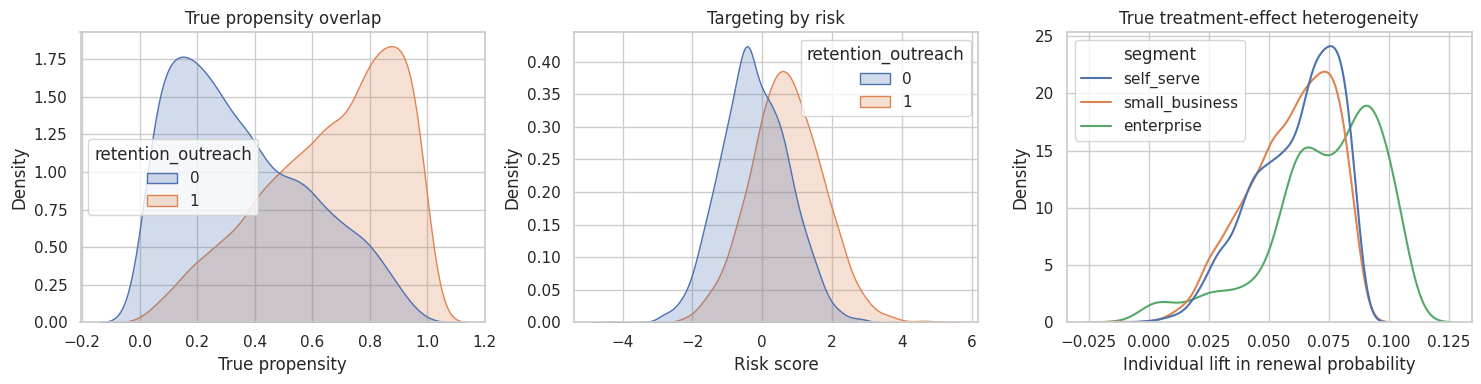

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.kdeplot(data=raw, x='propensity_true', hue='retention_outreach', common_norm=False, fill=True, alpha=0.25, ax=axes[0])
axes[0].set_title('True propensity overlap')
axes[0].set_xlabel('True propensity')

sns.kdeplot(data=raw, x='risk_score', hue='retention_outreach', common_norm=False, fill=True, alpha=0.25, ax=axes[1])
axes[1].set_title('Targeting by risk')
axes[1].set_xlabel('Risk score')

sns.kdeplot(data=raw, x='true_individual_lift', hue='segment', common_norm=False, fill=False, ax=axes[2])
axes[2].set_title('True treatment-effect heterogeneity')
axes[2].set_xlabel('Individual lift in renewal probability')
plt.tight_layout()
plt.show()

### Discussion

The treatment is not randomized. Treated customers tend to have higher risk scores. The effect is also heterogeneous: higher-risk customers often have more room for improvement, while very healthy customers may gain less from outreach. This combination makes the observed treated-versus-untreated contrast difficult to interpret.

## 7. Estimator Comparison Against Ground Truth

Now we fit several simple estimators. The point is not to choose the best production estimator. The point is to show how different specifications relate to the known truth.

In [11]:
FORMULAS = {
    'naive difference': 'renewed_30d ~ retention_outreach',
    'valid pre-treatment adjustment': (
        'renewed_30d ~ retention_outreach + tenure_months + prior_usage + prior_tickets + '
        'customer_value + baseline_health + risk_score + C(segment)'
    ),
    'bad mediator adjustment': (
        'renewed_30d ~ retention_outreach + tenure_months + prior_usage + prior_tickets + '
        'customer_value + baseline_health + risk_score + C(segment) + opened_outreach + used_discount + support_call_after_outreach'
    ),
    'future leakage adjustment': (
        'renewed_30d ~ retention_outreach + tenure_months + prior_usage + prior_tickets + '
        'customer_value + baseline_health + risk_score + C(segment) + future_retention_score'
    ),
    'selected survey responders': (
        'renewed_30d ~ retention_outreach + tenure_months + prior_usage + prior_tickets + '
        'customer_value + baseline_health + risk_score + C(segment)'
    ),
}

estimate_rows = []
for label, formula in FORMULAS.items():
    model_df = raw.copy()
    if label == 'selected survey responders':
        model_df = model_df.query('survey_responded == 1').copy()
    fitted = smf.ols(formula, data=model_df).fit(cov_type='HC3')
    estimate_rows.append(
        {
            'estimator': label,
            'rows_used': int(fitted.nobs),
            'estimated_effect': fitted.params.get('retention_outreach', np.nan),
            'robust_se': fitted.bse.get('retention_outreach', np.nan),
            'true_ate': truth['true_ate_renewal'],
            'bias_vs_true_ate': fitted.params.get('retention_outreach', np.nan) - truth['true_ate_renewal'],
            'r_squared': fitted.rsquared,
        }
    )

estimate_table = pd.DataFrame(estimate_rows)
estimate_table

,estimator,rows_used,estimated_effect,robust_se,true_ate,bias_vs_true_ate,r_squared
0,naive difference,6000,-0.110355,0.012391,0.062679,-0.173035,0.013035
1,valid pre-treatment adjustment,6000,0.068572,0.012233,0.062679,0.005893,0.238502
2,bad mediator adjustment,6000,0.064786,0.012824,0.062679,0.002107,0.238745
3,future leakage adjustment,6000,0.003189,0.003176,0.062679,-0.059491,0.948929
4,selected survey responders,2425,0.045201,0.016559,0.062679,-0.017478,0.218164


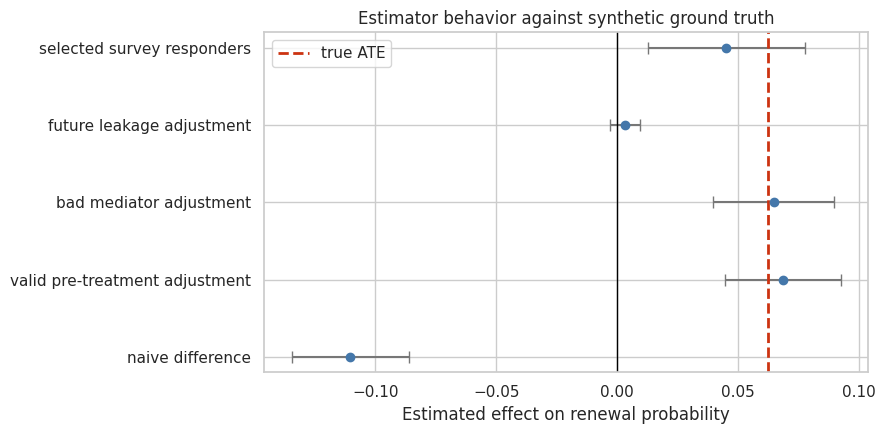

In [12]:
plot_estimates = estimate_table.assign(
    lower=lambda d: d['estimated_effect'] - 1.96 * d['robust_se'],
    upper=lambda d: d['estimated_effect'] + 1.96 * d['robust_se'],
)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(
    plot_estimates['estimated_effect'],
    plot_estimates['estimator'],
    xerr=[plot_estimates['estimated_effect'] - plot_estimates['lower'], plot_estimates['upper'] - plot_estimates['estimated_effect']],
    fmt='o',
    color='#4477AA',
    ecolor='#777777',
    capsize=4,
)
ax.axvline(truth['true_ate_renewal'], color='#CC3311', linestyle='--', linewidth=2, label='true ATE')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Estimator behavior against synthetic ground truth')
ax.set_xlabel('Estimated effect on renewal probability')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.show()

### Discussion

This plot is the whole reason to use synthetic data. We can see which estimators are near the truth and which are answering a different question.

The mediator-adjusted model may appear reasonable because post-treatment behaviors predict renewal. But it blocks treatment pathways. The future-leakage model can look impressive because it uses information generated after the outcome process. The survey-responder model changes the sample because response depends on treatment and renewal.

## 8. Stress Test: Confounding and Overlap

A good simulation should be easy to modify. Here we vary the strength of targeted assignment and the noise in the assignment rule. Stronger targeting and lower noise create worse overlap.

In [13]:
def estimate_naive_and_adjusted(df, truth_value):
    naive = smf.ols('renewed_30d ~ retention_outreach', data=df).fit(cov_type='HC3').params['retention_outreach']
    adjusted = smf.ols(
        'renewed_30d ~ retention_outreach + tenure_months + prior_usage + prior_tickets + customer_value + baseline_health + risk_score + C(segment)',
        data=df,
    ).fit(cov_type='HC3').params['retention_outreach']
    overlap_share = ((df['propensity_true'] > 0.10) & (df['propensity_true'] < 0.90)).mean()
    return naive, adjusted, overlap_share, naive - truth_value, adjusted - truth_value

stress_rows = []
for targeting_strength in [0.0, 0.5, 1.0, 1.6, 2.2]:
    for overlap_noise in [0.35, 0.85, 1.50]:
        sim_df, sim_truth = simulate_retention_outreach(
            n=4500,
            seed=SEED + int(targeting_strength * 100) + int(overlap_noise * 10),
            targeting_strength=targeting_strength,
            overlap_noise=overlap_noise,
        )
        naive, adjusted, overlap_share, naive_bias, adjusted_bias = estimate_naive_and_adjusted(sim_df, sim_truth['true_ate_renewal'])
        stress_rows.append(
            {
                'targeting_strength': targeting_strength,
                'overlap_noise': overlap_noise,
                'true_ate': sim_truth['true_ate_renewal'],
                'naive_estimate': naive,
                'adjusted_estimate': adjusted,
                'naive_bias': naive_bias,
                'adjusted_bias': adjusted_bias,
                'overlap_share_10_to_90': overlap_share,
                'treatment_rate': sim_truth['treatment_rate'],
            }
        )

stress_table = pd.DataFrame(stress_rows)
stress_table.head()

,targeting_strength,overlap_noise,true_ate,naive_estimate,adjusted_estimate,naive_bias,adjusted_bias,overlap_share_10_to_90,treatment_rate
0,0.0,0.35,0.062860,0.066142,0.074793,0.003281,0.011933,1.000000,0.435556
1,0.0,0.85,0.062729,0.047392,0.059692,-0.015337,-0.003038,0.985556,0.446889
2,0.0,1.50,0.062477,0.054277,0.068094,-0.008201,0.005617,0.862667,0.464222
3,0.5,0.35,0.062484,-0.094658,0.021683,-0.157142,-0.040802,0.995556,0.480667
4,0.5,0.85,0.062981,-0.101839,0.013490,-0.164820,-0.049491,0.950889,0.484000


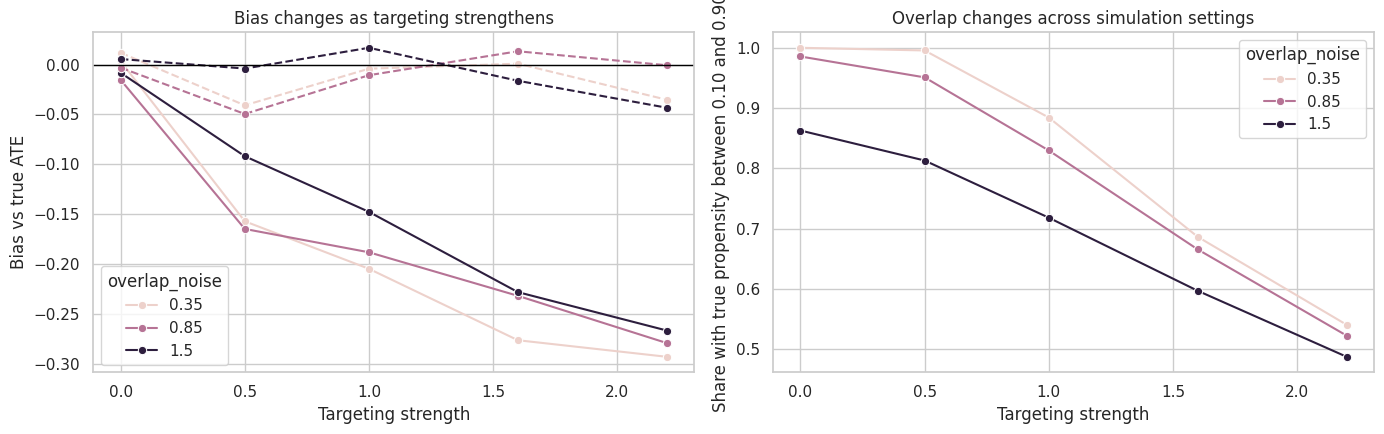

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=stress_table, x='targeting_strength', y='naive_bias', hue='overlap_noise', marker='o', ax=axes[0])
sns.lineplot(data=stress_table, x='targeting_strength', y='adjusted_bias', hue='overlap_noise', marker='o', ax=axes[0], linestyle='--', legend=False)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Bias changes as targeting strengthens')
axes[0].set_ylabel('Bias vs true ATE')
axes[0].set_xlabel('Targeting strength')

sns.lineplot(data=stress_table, x='targeting_strength', y='overlap_share_10_to_90', hue='overlap_noise', marker='o', ax=axes[1])
axes[1].set_title('Overlap changes across simulation settings')
axes[1].set_ylabel('Share with true propensity between 0.10 and 0.90')
axes[1].set_xlabel('Targeting strength')
plt.tight_layout()
plt.show()

### Discussion

The stress test turns a single example into a small laboratory. When targeting is weak, the naive estimator may look less bad. When targeting is strong and overlap is poor, even adjusted estimators become more fragile.

This is exactly the kind of simulation grid an AI assistant can help propose, but the code and truth calculation must stay deterministic.

## 9. Build a Simulation Review Bundle

Now we create a compact bundle for the AI reviewer. It includes the simulation card, variable roles, truth summary, estimator comparison, and stress-test summary.

The LLM task is not to estimate the effect. The task is to review whether the synthetic data is suitable for teaching the intended causal lesson.

In [15]:
def dataframe_records(df, max_rows=30):
    return json.loads(df.head(max_rows).to_json(orient='records', date_format='iso'))

review_bundle = {
    'simulation_card': simulation_card,
    'variable_dictionary': dataframe_records(variable_dictionary, max_rows=40),
    'truth_summary': truth,
    'observed_summary': dataframe_records(summary_table, max_rows=20),
    'estimator_comparison': dataframe_records(estimate_table, max_rows=20),
    'stress_test_summary': dataframe_records(stress_table, max_rows=20),
    'forbidden_claims': [
        'Do not claim this synthetic result proves the intervention works in the real world.',
        'Do not recommend using potential-outcome columns as real covariates.',
        'Do not treat post-treatment variables or future scores as valid total-effect controls.',
    ],
}

print(json.dumps(review_bundle, indent=2)[:4500])

{
  "simulation_card": {
    "title": "Retention outreach for subscription customers",
    "unit": "customer",
    "treatment": "retention_outreach",
    "primary_outcome": "renewed_30d",
    "secondary_outcome": "revenue_30d",
    "estimand": "ATE of retention_outreach on renewed_30d in the simulated customer population",
    "assignment": "Observational targeting: higher-risk and higher-value customers are more likely to receive outreach.",
    "ground_truth": "Both potential renewal probabilities are generated before the observed outcome is sampled.",
    "pre_treatment_confounders": [
      "segment",
      "tenure_months",
      "prior_usage",
      "prior_tickets",
      "baseline_health",
      "customer_value",
      "risk_score"
    ],
    "post_treatment_variables": [
      "opened_outreach",
      "used_discount",
      "support_call_after_outreach"
    ],
    "selection_or_leakage_variables": [
      "survey_responded",
      "future_retention_score"
    ],
    "intended_le

### Discussion

The bundle gives the model the right evidence and the right constraints. It also includes explicit forbidden claims. That matters because LLMs often move too quickly from “this simulation shows” to “therefore the real intervention works.”

## 10. Shared Local LLM Runtime

We reuse the shared local LLM utilities from `notebooks/_shared`. This keeps model loading consistent with the rest of Course 05.

In [16]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


## 11. Structured AI Simulation Review

We now ask the LLM to review the simulation design. The output schema forces it to name the teaching objective, ground truth, expected estimator behavior, and limitations.

In [17]:
class SimulationReview(BaseModel):
    teaching_goal: str = Field(description='The causal lesson this simulation is meant to teach.')
    estimand: str = Field(description='The target causal estimand in the synthetic world.')
    ground_truth_available: list[str] = Field(description='Ground-truth quantities available because this is synthetic.')
    valid_adjustment_candidates: list[str] = Field(description='Pre-treatment variables that may be valid adjustment candidates.')
    bad_controls_or_leakage: list[str] = Field(description='Variables that should not be used as ordinary total-effect controls.')
    expected_estimator_behavior: list[str] = Field(description='Expected behavior of naive, adjusted, bad-control, and leaky estimators.')
    stress_tests_to_add: list[str] = Field(description='Additional simulation stress tests worth adding.')
    limitations: list[str] = Field(description='What this simulation cannot prove about the real world.')
    reviewer_warnings: list[str] = Field(description='Warnings to include before students interpret results.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the review given the provided bundle.')

REVIEW_SCALAR_FIELDS = ['teaching_goal', 'estimand', 'confidence']
REVIEW_LIST_FIELDS = [
    'ground_truth_available',
    'valid_adjustment_candidates',
    'bad_controls_or_leakage',
    'expected_estimator_behavior',
    'stress_tests_to_add',
    'limitations',
    'reviewer_warnings',
]
REVIEW_ALIASES = {
    'goal': 'teaching_goal',
    'target_estimand': 'estimand',
    'ground_truth': 'ground_truth_available',
    'valid_controls': 'valid_adjustment_candidates',
    'bad_controls': 'bad_controls_or_leakage',
    'leakage_variables': 'bad_controls_or_leakage',
    'estimator_behavior': 'expected_estimator_behavior',
    'stress_tests': 'stress_tests_to_add',
    'warnings': 'reviewer_warnings',
}


def parse_simulation_review(raw_output):
    result = parse_pydantic_output(
        raw_output,
        SimulationReview,
        scalar_fields=REVIEW_SCALAR_FIELDS,
        list_fields=REVIEW_LIST_FIELDS,
        field_aliases=REVIEW_ALIASES,
        defaults={'confidence': 'medium'},
    )
    return result.parsed, result.json_text, result.notes

In [18]:
SYSTEM_REVIEW_MESSAGE = (
    'You are a careful causal inference simulation reviewer.\n'
    'Rules:\n'
    '- Use only the provided simulation review bundle.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Distinguish synthetic ground truth from real-world evidence.\n'
    '- Do not claim the simulated intervention works in production.\n'
    '- Do not recommend using potential-outcome truth columns as real covariates.\n'
    '- Do not recommend post-treatment variables, survey selection, or future scores as total-effect controls.\n'
    '- Use exact variable names whenever possible.'
)


def build_review_prompt(bundle):
    schema_hint = {
        'teaching_goal': 'string',
        'estimand': 'string',
        'ground_truth_available': ['string'],
        'valid_adjustment_candidates': ['string'],
        'bad_controls_or_leakage': ['string'],
        'expected_estimator_behavior': ['string'],
        'stress_tests_to_add': ['string'],
        'limitations': ['string'],
        'reviewer_warnings': ['string'],
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce a SimulationReview JSON object using this schema:
        {json.dumps(schema_hint, indent=2)}

        Simulation review bundle:
        {json.dumps(bundle, indent=2)}
        '''
    ).strip()

review_prompt = build_review_prompt(review_bundle)
print(review_prompt[:3000])

Produce a SimulationReview JSON object using this schema:
        {
  "teaching_goal": "string",
  "estimand": "string",
  "ground_truth_available": [
    "string"
  ],
  "valid_adjustment_candidates": [
    "string"
  ],
  "bad_controls_or_leakage": [
    "string"
  ],
  "expected_estimator_behavior": [
    "string"
  ],
  "stress_tests_to_add": [
    "string"
  ],
  "limitations": [
    "string"
  ],
  "reviewer_warnings": [
    "string"
  ],
  "confidence": "low | medium | high"
}

        Simulation review bundle:
        {
  "simulation_card": {
    "title": "Retention outreach for subscription customers",
    "unit": "customer",
    "treatment": "retention_outreach",
    "primary_outcome": "renewed_30d",
    "secondary_outcome": "revenue_30d",
    "estimand": "ATE of retention_outreach on renewed_30d in the simulated customer population",
    "assignment": "Observational targeting: higher-risk and higher-value customers are more likely to receive outreach.",
    "ground_truth": "

## 12. Run One Local Model

The first live call asks the fast local model to review the simulation. The answer should recognize that synthetic ground truth exists while still warning that simulation evidence is not real-world evidence.

In [19]:
if RUN_LIVE_LOCAL_LLM:
    raw_review_output = local_chat(
        review_prompt,
        system_message=SYSTEM_REVIEW_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    display(Markdown('### Raw model output'))
    display(Markdown(f'```json\n{clean_generated_text(raw_review_output)}\n```'))
else:
    raw_review_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "teaching_goal": "Understand the impact of targeting on causal inference and the importance of valid pre-treatment adjustment.",
 "estimand": "ATE of retention_outreach on renewed_30d in the simulated customer population",
 "ground_truth_available": [
 "p0_renewal",
 "p1_renewal",
 "true_individual_lift"
 ],
 "valid_adjustment_candidates": [
 "segment",
 "tenure_months",
 "prior_usage",
 "prior_tickets",
 "baseline_health",
 "customer_value",
 "risk_score"
 ],
 "bad_controls_or_leakage": [
 "opened_outreach",
 "used_discount",
 "support_call_after_outreach",
 "survey_responded",
 "future_retention_score"
 ],
 "expected_estimator_behavior": [
 "Naive difference estimator will be biased due to targeting.",
 "Valid pre-treatment adjustment will provide an unbiased estimate of the ATE.",
 "Bad mediator adjustment (e.g., opened_outreach) will also provide a biased estimate but closer to the true ATE than naive estimates.",
 "Future leakage adjustment and selected survey responders will provide biased estimates due to post-treatment variables and selection bias, respectively."
 ],
 "stress_tests_to_add": [
 "Vary the strength of targeting and overlap noise to observe how these factors affect the performance of different estimators."
 ],
 "limitations": [
 "The simulation assumes a specific form of targeting and does not account for all possible forms of targeting bias.",
 "The true individual lift is not directly observable in real-world data, making it difficult to validate individual-level causal effects."
 ],
 "reviewer_warnings": [
 "Be cautious when interpreting results from simulations with strong targeting, as they may not generalize to weaker targeting scenarios.",
 "Avoid using post-treatment variables or future scores as controls for estimating the total effect of the treatment."
 ],
 "confidence": "medium"
}
```

In [20]:
if raw_review_output:
    try:
        simulation_review, simulation_review_json, review_parser_notes = parse_simulation_review(raw_review_output)
        single_model_parse_error = ''
        display(Markdown('### Parsed simulation review'))
        display(Markdown(f'```json\n{simulation_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', review_parser_notes)
    except Exception as error:
        simulation_review = None
        simulation_review_json = ''
        review_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    simulation_review = None
    simulation_review_json = ''
    review_parser_notes = []
    single_model_parse_error = ''

### Parsed simulation review

```json
{
  "teaching_goal": "Understand the impact of targeting on causal inference and the importance of valid pre-treatment adjustment.",
  "estimand": "ATE of retention_outreach on renewed_30d in the simulated customer population",
  "ground_truth_available": [
    "p0_renewal",
    "p1_renewal",
    "true_individual_lift"
  ],
  "valid_adjustment_candidates": [
    "segment",
    "tenure_months",
    "prior_usage",
    "prior_tickets",
    "baseline_health",
    "customer_value",
    "risk_score"
  ],
  "bad_controls_or_leakage": [
    "opened_outreach",
    "used_discount",
    "support_call_after_outreach",
    "survey_responded",
    "future_retention_score"
  ],
  "expected_estimator_behavior": [
    "Naive difference estimator will be biased due to targeting.",
    "Valid pre-treatment adjustment will provide an unbiased estimate of the ATE.",
    "Bad mediator adjustment (e.g., opened_outreach) will also provide a biased estimate but closer to the true ATE than naive estimates.",
    "Future leakage adjustment and selected survey responders will provide biased estimates due to post-treatment variables and selection bias, respectively."
  ],
  "stress_tests_to_add": [
    "Vary the strength of targeting and overlap noise to observe how these factors affect the performance of different estimators."
  ],
  "limitations": [
    "The simulation assumes a specific form of targeting and does not account for all possible forms of targeting bias.",
    "The true individual lift is not directly observable in real-world data, making it difficult to validate individual-level causal effects."
  ],
  "reviewer_warnings": [
    "Be cautious when interpreting results from simulations with strong targeting, as they may not generalize to weaker targeting scenarios.",
    "Avoid using post-treatment variables or future scores as controls for estimating the total effect of the treatment."
  ],
  "confidence": "medium"
}
```

Parser notes: []


## 13. Audit the AI Review

A useful simulation review must preserve three boundaries:

1. Synthetic truth is available only because we generated it.
2. Post-treatment and future variables are not valid total-effect controls.
3. Simulation results do not prove real-world impact.

In [21]:
BAD_CONTROL_TERMS = {
    'opened_outreach',
    'used_discount',
    'support_call_after_outreach',
    'survey_responded',
    'future_retention_score',
    'p0_renewal',
    'p1_renewal',
    'true_individual_lift',
}
EXPECTED_VALID_TERMS = {
    'segment',
    'tenure_months',
    'prior_usage',
    'prior_tickets',
    'customer_value',
    'baseline_health',
    'risk_score',
}


def review_text(review):
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    return any(term.lower() in text for term in terms)


def score_simulation_review(review):
    text = review_text(review)
    valid_text = ' '.join(review.valid_adjustment_candidates).lower() if review is not None else ''
    checks = {
        'states teaching goal': contains_any(text, ['synthetic', 'teaching', 'confounding', 'ground truth']),
        'states estimand': 'retention_outreach' in text and 'renewed_30d' in text and 'ate' in text,
        'names ground truth quantities': sum(term in text for term in ['p0_renewal', 'p1_renewal', 'true_individual_lift', 'true_ate']) >= 2,
        'names valid pre-treatment candidates': sum(term in text for term in EXPECTED_VALID_TERMS) >= 5,
        'flags bad controls or leakage': sum(term in text for term in ['opened_outreach', 'used_discount', 'support_call_after_outreach', 'future_retention_score']) >= 3,
        'warns about survey selection': 'survey_responded' in text,
        'mentions estimator behavior': contains_any(text, ['naive', 'adjusted', 'mediator', 'leakage']),
        'suggests stress tests': len(review.stress_tests_to_add) >= 2 if review is not None else False,
        'does not overclaim real-world evidence': not contains_any(text, ['proves the intervention works', 'production effect is established', 'real-world impact is proven']),
        'valid adjustment list excludes truth and post-treatment columns': not contains_any(valid_text, BAD_CONTROL_TERMS),
        'includes limitations': len(review.limitations) >= 2 if review is not None else False,
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit)

if simulation_review is not None:
    single_audit, single_score, single_max_score = score_simulation_review(simulation_review)
    print(f'Score: {single_score}/{single_max_score}')
    display(single_audit)
else:
    print('No simulation review to audit because live model execution was skipped or parsing failed.')

Score: 10/11


,check,passed,credit
0,states teaching goal,True,1
1,states estimand,True,1
2,names ground truth quantities,True,1
3,names valid pre-treatment candidates,True,1
4,flags bad controls or leakage,True,1
5,warns about survey selection,True,1
6,mentions estimator behavior,True,1
7,suggests stress tests,False,0
8,does not overclaim real-world evidence,True,1
9,valid adjustment list excludes truth and post-treatment columns,True,1


### Discussion

The audit does not grade prose elegance. It checks whether the model preserved the synthetic-data contract. Did it name the ground truth? Did it keep post-treatment variables out of the adjustment list? Did it avoid converting a toy simulation into a production claim?

Those are the failure modes that matter.

## 14. Optional All-Model Comparison

We now compare all local models on the same simulation-review task.

The exact ranking can change across reruns and environments. That is expected. The durable lesson is that synthetic data gives us unusually clear audit criteria: we know the truth, we know which variables are forbidden, and we know what claims are out of scope.

In [22]:
SIMULATION_EVAL_CASES = [
    {
        'case_id': 'retention_outreach_simulation_review',
        'bundle': review_bundle,
    }
]

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_review_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used',
    'repair_stage', 'error_type', 'review_score', 'max_review_score', 'review_score_share',
    'error', 'raw_output_preview'
]

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required SimulationReview JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_simulation_review():
    return SimulationReview(
        teaching_goal='',
        estimand='',
        ground_truth_available=[],
        valid_adjustment_candidates=[],
        bad_controls_or_leakage=[],
        expected_estimator_behavior=[],
        stress_tests_to_add=[],
        limitations=[],
        reviewer_warnings=[],
        confidence='low',
    )


def parse_or_repair_review(raw_output, model_id):
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_simulation_review(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': notes,
            'repair_used': bool(notes),
            'repair_stage': 'parser' if notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:7000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_simulation_review(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def run_single_model_review_case(label, model_id, role, case):
    prompt = build_review_prompt(case['bundle'])
    raw_output = ''
    max_score = score_simulation_review(empty_simulation_review())[2]
    try:
        raw_output = local_chat(
            prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed_result = parse_or_repair_review(raw_output, model_id)
        audit, score, max_score = score_simulation_review(parsed_result['parsed'])
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'ok',
            'schema_valid': True,
            'repair_used': parsed_result['repair_used'],
            'repair_stage': parsed_result['repair_stage'],
            'error_type': '',
            'review_score': score,
            'max_review_score': max_score,
            'review_score_share': score / max_score if max_score else 0.0,
            'error': '',
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }
    except Exception as error:
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'failed',
            'schema_valid': False,
            'repair_used': False,
            'repair_stage': 'failed',
            'error_type': classify_structured_output_failure(error),
            'review_score': 0,
            'max_review_score': max_score,
            'review_score_share': 0.0,
            'error': clean_generated_text(repr(error))[:900],
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }


def summarize_model_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results
        .groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_review_score=('review_score_share', 'mean'),
            failure_types=('error_type', lambda values: sorted({value for value in values if value})),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_review_score', 'schema_reliability'], ascending=False)


def run_all_model_review_comparison(models_to_compare=MODELS_TO_COMPARE, cases=SIMULATION_EVAL_CASES):
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_review_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    simulation_model_summary, simulation_case_results = run_all_model_review_comparison()
else:
    simulation_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    simulation_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

simulation_model_summary

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_review_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,1,1,1,1.0,1.000000,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,1,1,1,1.0,0.909091,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,1,1,0,1.0,0.909091,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,1,1,0,1.0,0.909091,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,1,1,0,1.0,0.818182,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,1,1,0,1.0,0.727273,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,1,1,0,1.0,0.727273,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,1,1,0,1.0,0.636364,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,1,1,0,1.0,0.454545,[]


### Inspecting Failed Model Runs

A failed model run receives zero workflow credit instead of producing a `NaN` score. Synthetic-data review is a useful place to expose these failures because the expected answer is unusually explicit.

In [23]:
failed_model_details = simulation_case_results.loc[
    ~simulation_case_results['schema_valid'],
    ['label', 'status', 'error_type', 'error', 'raw_output_preview'],
].reset_index(drop=True)
failed_model_details

,label,status,error_type,error,raw_output_preview


### Interpreting Repair Counts

Repairs are not automatically failures. They show whether parser normalization or model retry was needed before the output became usable.

In [24]:
def summarize_repair_stages(case_results):
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(simulation_case_results)

,repair_stage,cases
0,none,7
1,parser,2


## 15. A Reusable Synthetic-Data Checklist

A strong synthetic data notebook should make these items explicit before learners see any estimator output.

In [25]:
synthetic_data_checklist = pd.DataFrame(
    [
        {'check': 'Unit and estimand are stated', 'example from notebook': 'customer-level ATE of retention_outreach on renewed_30d'},
        {'check': 'Potential outcomes are generated explicitly', 'example from notebook': 'p0_renewal and p1_renewal'},
        {'check': 'Observed treatment assignment is documented', 'example from notebook': 'risk and value targeting through propensity_true'},
        {'check': 'Ground-truth effect is calculated from potential outcomes', 'example from notebook': 'true_individual_lift mean'},
        {'check': 'Observed data hides counterfactuals from estimators', 'example from notebook': 'estimators use renewed_30d, not p0/p1'},
        {'check': 'Bad controls and leakage are intentionally labeled', 'example from notebook': 'opened_outreach, used_discount, future_retention_score'},
        {'check': 'Estimator comparisons include invalid specifications for teaching', 'example from notebook': 'bad mediator and future leakage adjustments'},
        {'check': 'Stress tests vary assignment and overlap', 'example from notebook': 'targeting_strength and overlap_noise grid'},
        {'check': 'AI review is audited against synthetic truth', 'example from notebook': 'score_simulation_review'},
    ]
)
synthetic_data_checklist

,check,example from notebook
0,Unit and estimand are stated,customer-level ATE of retention_outreach on renewed_30d
1,Potential outcomes are generated explicitly,p0_renewal and p1_renewal
2,Observed treatment assignment is documented,risk and value targeting through propensity_true
3,Ground-truth effect is calculated from potential outcomes,true_individual_lift mean
4,Observed data hides counterfactuals from estimators,"estimators use renewed_30d, not p0/p1"
5,Bad controls and leakage are intentionally labeled,"opened_outreach, used_discount, future_retention_score"
6,Estimator comparisons include invalid specifications for teaching,bad mediator and future leakage adjustments
7,Stress tests vary assignment and overlap,targeting_strength and overlap_noise grid
8,AI review is audited against synthetic truth,score_simulation_review


## 16. Exercises

1. Set `targeting_strength=0` and rerun the estimator comparison. What happens to the naive estimate?
2. Increase `treatment_effect_scale` and inspect how treatment-effect heterogeneity changes.
3. Add a collider called `success_story_featured` that depends on both treatment and renewal. Show what happens if you restrict to featured customers.
4. Modify the DGP so treatment harms low-risk customers but helps high-risk customers. Compare ATE and ATT.
5. Ask one local model to propose three additional stress tests, then decide which are scientifically meaningful and which are cosmetic.
6. Remove the forbidden-claims section from the review bundle and compare whether models overclaim more often.

## Key Takeaways

Synthetic data is a powerful teaching tool because it exposes the gap between observed data and causal truth.

A strong synthetic-data workflow has this shape:

1. Document the simulation before coding.
2. Generate potential outcomes and treatment assignment explicitly.
3. Keep ground-truth columns for teaching, but do not let estimators use them.
4. Include confounding, mediators, selection, and leakage on purpose.
5. Compare estimators against the true estimand.
6. Stress-test assumptions by changing the DGP.
7. Use AI to critique and explain the simulation, then audit the AI against known truth.

The guiding principle is simple: synthetic data creates a known world; causal teaching comes from watching methods and models succeed or fail inside that world.